### 임베딩 모델: https://github.com/nlpai-lab/KURE

In [1]:
! pip install sentence-transformers xgboost scikit-learn pandas numpy tqdm

  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 10.1/10.1 MB 52.8 MB/s  0:00:00
   ---------------------------------------- 0.0/536.7 kB ? 

In [2]:
import os
import re
import random
import zipfile
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# 0) Reproducibility / Device
# ---------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("DEVICE =", DEVICE)


# ---------------------------
# 1) Data Locate / Load
# ---------------------------
def locate_data_dir():
    """
    train.csv / test.csv / sample_submission.csv 를 찾고,
    없으면 현재 디렉토리의 zip 파일에서 자동 추출을 시도.
    """
    cwd = Path(".").resolve()

    # 1) 현재 폴더에 바로 존재
    if (cwd / "train.csv").exists() and (cwd / "test.csv").exists():
        return cwd
    
    # 1-1) open 폴더에 존재
    if (cwd / "open" / "train.csv").exists() and (cwd / "open" / "test.csv").exists():
        return cwd / "open"

    # 2) 하위 폴더에서 탐색
    candidates = list(cwd.rglob("train.csv"))
    for tr in candidates:
        te = tr.parent / "test.csv"
        ss = tr.parent / "sample_submission.csv"
        if te.exists() and ss.exists():
            return tr.parent

    # 3) zip 자동 추출 시도
    zips = list(cwd.rglob("*.zip"))
    if len(zips) > 0:
        out_dir = cwd / "_extracted_data"
        out_dir.mkdir(parents=True, exist_ok=True)

        extracted_any = False
        for z in zips:
            try:
                with zipfile.ZipFile(z, "r") as zz:
                    names = [Path(n).name for n in zz.namelist()]
                    if ("train.csv" in names) and ("test.csv" in names) and ("sample_submission.csv" in names):
                        zz.extractall(out_dir)
                        extracted_any = True
            except Exception:
                pass

        if extracted_any:
            candidates = list(out_dir.rglob("train.csv"))
            for tr in candidates:
                te = tr.parent / "test.csv"
                ss = tr.parent / "sample_submission.csv"
                if te.exists() and ss.exists():
                    return tr.parent

    raise FileNotFoundError("train.csv / test.csv / sample_submission.csv 를 찾지 못했습니다.")

DATA_DIR = locate_data_dir()
print("DATA_DIR =", DATA_DIR)

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

TARGET = "completed"
ID_COL = "ID"

assert TARGET in train.columns, "train에 completed 컬럼이 없습니다."
assert TARGET not in test.columns, "test에 completed 컬럼이 있으면 안 됩니다."
assert ID_COL in train.columns and ID_COL in test.columns and ID_COL in sub.columns

print("\n[EDA] Shapes")
print("train:", train.shape, "test:", test.shape, "sub:", sub.shape)

print("\n[EDA] Target distribution")
y = train[TARGET].astype(int).values
print(pd.Series(y).value_counts().sort_index())
print("pos_rate =", y.mean())


# ---------------------------
# 2) KoE5 모델 로드
# ---------------------------
print("\n[Model] Loading KoE5 embedding model...")
embedding_model = SentenceTransformer("nlpai-lab/KoE5")
print("[Model] KoE5 loaded successfully!")


# ---------------------------
# 3) 텍스트 전처리 함수
# ---------------------------
MISSING_MARKERS = {
    "", " ", "  ", "\t", "\n", "\r",
    "nan", "none", "null", "n/a", "na",
    ".", "-", "–", "—", "_", "x"
}
NONE_EQUIV = {
    "없음", "없습니다", "없어요", "없다", "해당없음", "해당 없음",
    "딱히 없음", "아직 없음", "아직없음", "무", "무응답", "미응답"
}

def _nfkc(s: str) -> str:
    return unicodedata.normalize("NFKC", s)

def canonicalize_token(s: str) -> str:
    s = _nfkc(str(s)).strip()
    if s == "":
        return ""
    s_low = s.lower().strip()
    if s_low in MISSING_MARKERS:
        return ""
    if s in NONE_EQUIV or s_low in NONE_EQUIV:
        return "없음"
    return s

def normalize_text(x) -> str:
    """텍스트 정규화"""
    if pd.isna(x):
        return ""
    if isinstance(x, (bool, np.bool_)):
        return "예" if bool(x) else "아니오"
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, (float, np.floating)):
        if np.isfinite(x) and abs(x - int(round(x))) < 1e-9:
            return str(int(round(x)))
        return str(x)

    s = canonicalize_token(x)
    if s == "":
        return ""
    s = re.sub(r"[\r\n\t]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


# ---------------------------
# 4) 컬럼 분류 및 텍스트 결합
# ---------------------------
# 텍스트 컬럼과 정형 컬럼 자동 분류
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET] and c in test.columns]

# 텍스트 컬럼 식별 (서술형 응답이 많은 컬럼)
def identify_text_columns(df, cols, min_avg_len=20, min_unique_ratio=0.3):
    """서술형 텍스트 컬럼을 식별"""
    text_cols = []
    for col in cols:
        if df[col].dtype != 'object':
            continue
        non_null = df[col].dropna().astype(str)
        if len(non_null) < 10:
            continue
        avg_len = non_null.str.len().mean()
        unique_ratio = non_null.nunique() / len(non_null)
        # 평균 길이가 길고 고유값 비율이 높으면 서술형
        if avg_len >= min_avg_len and unique_ratio >= min_unique_ratio:
            text_cols.append(col)
    return text_cols

# 강제 텍스트 컬럼 (서술형 질문)
FORCE_TEXT_COLS = [
    'whyBDA', 'what_to_gain', 'future_plan', 'incumbents_lecture_scale_reason',
    'desired_job_detail', 'desired_job_except_data', 'bda_plus_value'
]

auto_text_cols = identify_text_columns(train, feature_cols)
text_cols = list(set(auto_text_cols) | set([c for c in FORCE_TEXT_COLS if c in feature_cols]))
structured_cols = [c for c in feature_cols if c not in text_cols]

print(f"\n[Feature] 텍스트 컬럼 ({len(text_cols)}개): {text_cols[:5]}...")
print(f"[Feature] 정형 컬럼 ({len(structured_cols)}개): {structured_cols[:5]}...")


# ---------------------------
# 5) 텍스트 결합 및 임베딩
# ---------------------------
def build_combined_text(row, text_columns):
    """여러 텍스트 컬럼을 하나로 결합"""
    segments = []
    for col in text_columns:
        val = normalize_text(row[col])
        if val and val != "없음":
            segments.append(f"{col}: {val}")
    return " | ".join(segments) if segments else "정보없음"

print("\n[Processing] 텍스트 결합 중...")
train['combined_text'] = train.apply(lambda row: build_combined_text(row, text_cols), axis=1)
test['combined_text'] = test.apply(lambda row: build_combined_text(row, text_cols), axis=1)

# 텍스트 길이 기반 성실성 파생변수
train['text_total_length'] = train['combined_text'].apply(len)
train['text_word_count'] = train['combined_text'].apply(lambda x: len(x.split()))
test['text_total_length'] = test['combined_text'].apply(len)
test['text_word_count'] = test['combined_text'].apply(lambda x: len(x.split()))

print(f"[Processing] 텍스트 길이 분포: mean={train['text_total_length'].mean():.1f}, max={train['text_total_length'].max()}")

# KoE5 임베딩 (passage: 접두어 추가)
def get_koe5_embeddings(texts, model, batch_size=32):
    """KoE5 모델로 임베딩 생성 (E5 모델은 passage: 접두어 권장)"""
    # E5 모델 형식에 맞게 접두어 추가
    formatted_texts = [f"passage: {text}" for text in texts]
    
    all_embeddings = []
    for i in tqdm(range(0, len(formatted_texts), batch_size), desc="Embedding"):
        batch = formatted_texts[i:i+batch_size]
        embeddings = model.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        all_embeddings.append(embeddings)
    
    return np.vstack(all_embeddings)

print("\n[Embedding] Train 데이터 임베딩 중...")
train_embeddings = get_koe5_embeddings(train['combined_text'].tolist(), embedding_model)
print(f"Train embeddings shape: {train_embeddings.shape}")

print("\n[Embedding] Test 데이터 임베딩 중...")
test_embeddings = get_koe5_embeddings(test['combined_text'].tolist(), embedding_model)
print(f"Test embeddings shape: {test_embeddings.shape}")


# ---------------------------
# 6) PCA 차원 축소 (과적합 방지)
# ---------------------------
# 데이터 수(~750) < 임베딩 차원(1024) 이므로 차원 축소 필수
N_COMPONENTS = 32  # 16~32 권장

print(f"\n[PCA] 차원 축소: {train_embeddings.shape[1]} -> {N_COMPONENTS}")
pca = PCA(n_components=N_COMPONENTS, random_state=42)
train_pca = pca.fit_transform(train_embeddings)
test_pca = pca.transform(test_embeddings)

explained_var = sum(pca.explained_variance_ratio_)
print(f"[PCA] 설명 분산 비율: {explained_var:.4f} ({explained_var*100:.1f}%)")

# 임베딩 피처 DataFrame
emb_cols = [f'emb_{i}' for i in range(N_COMPONENTS)]
train_emb_df = pd.DataFrame(train_pca, columns=emb_cols, index=train.index)
test_emb_df = pd.DataFrame(test_pca, columns=emb_cols, index=test.index)


# ---------------------------
# 7) 정형 데이터 전처리
# ---------------------------
def preprocess_structured(train_df, test_df, structured_columns):
    """정형 데이터 전처리 (Label Encoding)"""
    train_processed = train_df.copy()
    test_processed = test_df.copy()
    
    label_encoders = {}
    
    for col in structured_columns:
        if col not in train_df.columns:
            continue
            
        # 결측치 처리
        train_processed[col] = train_processed[col].fillna('missing')
        test_processed[col] = test_processed[col].fillna('missing')
        
        if train_df[col].dtype == 'object':
            # 범주형: Label Encoding
            le = LabelEncoder()
            # train + test 합쳐서 fit (unseen 카테고리 방지)
            all_values = pd.concat([train_processed[col], test_processed[col]]).astype(str)
            le.fit(all_values)
            
            train_processed[col] = le.transform(train_processed[col].astype(str))
            test_processed[col] = le.transform(test_processed[col].astype(str))
            label_encoders[col] = le
        else:
            # 수치형: 결측치를 -1로
            train_processed[col] = pd.to_numeric(train_processed[col], errors='coerce').fillna(-1)
            test_processed[col] = pd.to_numeric(test_processed[col], errors='coerce').fillna(-1)
    
    return train_processed[structured_columns], test_processed[structured_columns], label_encoders

print("\n[Preprocessing] 정형 데이터 전처리 중...")
train_struct, test_struct, encoders = preprocess_structured(train, test, structured_cols)
print(f"정형 피처 수: {len(structured_cols)}")


# ---------------------------
# 8) 최종 피처 결합
# ---------------------------
# 텍스트 성실성 피처
text_stat_cols = ['text_total_length', 'text_word_count']
train_text_stat = train[text_stat_cols]
test_text_stat = test[text_stat_cols]

# 최종 X 데이터 생성
X_train = pd.concat([train_struct.reset_index(drop=True), 
                     train_text_stat.reset_index(drop=True),
                     train_emb_df.reset_index(drop=True)], axis=1)
X_test = pd.concat([test_struct.reset_index(drop=True), 
                    test_text_stat.reset_index(drop=True),
                    test_emb_df.reset_index(drop=True)], axis=1)

print(f"\n[Final] 최종 피처 수: {X_train.shape[1]}")
print(f"  - 정형 피처: {len(structured_cols)}")
print(f"  - 텍스트 통계: {len(text_stat_cols)}")  
print(f"  - 임베딩 (PCA): {N_COMPONENTS}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


# ---------------------------
# 9) Stratified K-Fold + XGBoost 학습
# ---------------------------
N_SPLITS = 5
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_pred = np.zeros(len(train))
oof_prob = np.zeros(len(train))
test_prob_folds = []
fold_scores = []

print("\n" + "="*60)
print("[Training] Stratified K-Fold XGBoost")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    print(f"\n[Fold {fold}/{N_SPLITS}]")
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # XGBoost 모델 (imbalanced 데이터 대응)
    scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    
    model = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_lambda=1.0,
        reg_alpha=0.1,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Validation 예측
    val_prob = model.predict_proba(X_val)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)
    
    # 최적 threshold 탐색
    best_thr, best_f1 = 0.5, 0
    for thr in np.arange(0.3, 0.7, 0.01):
        pred_thr = (val_prob >= thr).astype(int)
        f1_thr = f1_score(y_val, pred_thr, zero_division=0)
        if f1_thr > best_f1:
            best_f1 = f1_thr
            best_thr = thr
    
    val_pred_best = (val_prob >= best_thr).astype(int)
    f1 = f1_score(y_val, val_pred_best)
    prec = precision_score(y_val, val_pred_best, zero_division=0)
    rec = recall_score(y_val, val_pred_best, zero_division=0)
    
    print(f"  Best threshold: {best_thr:.2f}")
    print(f"  F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    
    oof_prob[val_idx] = val_prob
    oof_pred[val_idx] = val_pred_best
    fold_scores.append((fold, best_thr, f1))
    
    # Test 예측
    test_prob = model.predict_proba(X_test)[:, 1]
    test_prob_folds.append(test_prob)

# OOF 결과
print("\n" + "="*60)
print("[OOF Results]")
print("="*60)

# 전체 최적 threshold
best_global_thr, best_global_f1 = 0.5, 0
for thr in np.arange(0.3, 0.7, 0.005):
    pred_thr = (oof_prob >= thr).astype(int)
    f1_thr = f1_score(y, pred_thr, zero_division=0)
    if f1_thr > best_global_f1:
        best_global_f1 = f1_thr
        best_global_thr = thr

oof_pred_final = (oof_prob >= best_global_thr).astype(int)
oof_f1 = f1_score(y, oof_pred_final)
oof_prec = precision_score(y, oof_pred_final, zero_division=0)
oof_rec = recall_score(y, oof_pred_final, zero_division=0)

print(f"Global Best Threshold: {best_global_thr:.3f}")
print(f"OOF F1 Score: {oof_f1:.4f}")
print(f"OOF Precision: {oof_prec:.4f}")
print(f"OOF Recall: {oof_rec:.4f}")
print(f"OOF Positive Rate: {oof_pred_final.mean():.4f}")


# ---------------------------
# 10) Test 예측 및 제출 파일 생성
# ---------------------------
# Fold 앙상블 (평균)
test_prob_mean = np.mean(np.vstack(test_prob_folds), axis=0)
test_pred = (test_prob_mean >= best_global_thr).astype(int)

print(f"\n[Test Prediction]")
print(f"Threshold: {best_global_thr:.3f}")
print(f"Positive Rate: {test_pred.mean():.4f}")

# 제출 파일 생성
submission = sub.copy()
submission[TARGET] = test_pred.astype(int)

# 출력 디렉토리 설정
OUTPUT_PATH = "output/"

# 디렉토리가 없으면 생성
os.makedirs(OUTPUT_PATH, exist_ok=True)

# 기존 submission 파일 개수 확인하여 자동으로 번호 부여
counter = 1
while True:
    submission_path = OUTPUT_PATH + f'submission{counter}.csv'
    if not os.path.exists(submission_path):
        break
    counter += 1

# 저장
submission.to_csv(submission_path, index=False)

print(f"✅ 제출 파일 저장 완료: {submission_path}")
print("\\n[제출 파일 샘플]")
display(submission.head(10))

print("\\n" + "="*60)
print("🎉 모든 작업 완료!")
print("="*60)
print(f"📊 최종 모델: XGBoost + KoE5 Embedding")
print(f"📊 검증 F1 Score: {oof_f1:.4f}")
print(f"📊 제출 파일: {submission_path}")

c:\Users\dell\bda\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu
DATA_DIR = C:\Users\dell\bda\open

[EDA] Shapes
train: (748, 46) test: (814, 45) sub: (814, 2)

[EDA] Target distribution
0    525
1    223
Name: count, dtype: int64
pos_rate = 0.29812834224598933

[Model] Loading KoE5 embedding model...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1227.78it/s, Materializing param=pooler.dense.weight]                               


[Model] KoE5 loaded successfully!

[Feature] 텍스트 컬럼 (4개): ['what_to_gain', 'whyBDA', 'desired_job_except_data', 'incumbents_lecture_scale_reason']...
[Feature] 정형 컬럼 (40개): ['generation', 'school1', 'major type', 'major1_1', 'major1_2']...

[Processing] 텍스트 결합 중...
[Processing] 텍스트 길이 분포: mean=172.3, max=343

[Embedding] Train 데이터 임베딩 중...


Embedding: 100%|██████████| 24/24 [02:46<00:00,  6.92s/it]


Train embeddings shape: (748, 1024)

[Embedding] Test 데이터 임베딩 중...


Embedding: 100%|██████████| 26/26 [04:12<00:00,  9.73s/it]


Test embeddings shape: (814, 1024)

[PCA] 차원 축소: 1024 -> 32
[PCA] 설명 분산 비율: 0.9018 (90.2%)

[Preprocessing] 정형 데이터 전처리 중...
정형 피처 수: 40

[Final] 최종 피처 수: 74
  - 정형 피처: 40
  - 텍스트 통계: 2
  - 임베딩 (PCA): 32

X_train shape: (748, 74)
X_test shape: (814, 74)

[Training] Stratified K-Fold XGBoost

[Fold 1/5]
  Best threshold: 0.30
  F1: 0.4487 | Precision: 0.3153 | Recall: 0.7778

[Fold 2/5]
  Best threshold: 0.30
  F1: 0.4712 | Precision: 0.3082 | Recall: 1.0000

[Fold 3/5]
  Best threshold: 0.30
  F1: 0.4497 | Precision: 0.3065 | Recall: 0.8444

[Fold 4/5]
  Best threshold: 0.34
  F1: 0.4654 | Precision: 0.3217 | Recall: 0.8409

[Fold 5/5]
  Best threshold: 0.33
  F1: 0.4727 | Precision: 0.3223 | Recall: 0.8864

[OOF Results]
Global Best Threshold: 0.300
OOF F1 Score: 0.4521
OOF Precision: 0.3043
OOF Recall: 0.8789
OOF Positive Rate: 0.8610

[Test Prediction]
Threshold: 0.300
Positive Rate: 0.9582

[Saved] C:\Users\dell\bda\submission_koe5_1.csv
completed
1    780
0     34
Name: count, dtyp

In [3]:
## 🔧 추가 실험: MD 문서 기반 전처리 + KoE5 Only 모델

In [8]:
# ============================================================
# 📋 MD 문서 기반 데이터 전처리 함수
# ============================================================
# MISSING_VALUE_STRATEGY.md 참고하여 구현

def preprocess_with_md_strategy(train_df, test_df):
    """
    MD 문서(MISSING_VALUE_STRATEGY.md)에 정의된 결측치 처리 전략 적용
    
    처리 순서:
    1. 100% 결측치 컬럼 삭제 (contest_award, idea_contest)
    2. 수강 관련 결측치 -> "미수강" (-1)
    3. 이전 기수 수강 -> "신규학생"
    4. 대회 경험 -> "경험없음"
    5. 복수전공 -> "단일전공"
    6. 수치형 -> 중앙값
    7. 범주형 -> 최빈값
    8. 결측치 여부 파생 변수 생성
    """
    train_processed = train_df.copy()
    test_processed = test_df.copy()
    
    print("="*60)
    print("📋 MD 문서 기반 전처리 시작")
    print("="*60)
    
    # ---------------------------
    # 1단계: 100% 결측치 컬럼 삭제
    # ---------------------------
    cols_to_drop = ['contest_award', 'idea_contest']
    existing_drop = [c for c in cols_to_drop if c in train_processed.columns]
    if existing_drop:
        train_processed = train_processed.drop(columns=existing_drop, errors='ignore')
        test_processed = test_processed.drop(columns=existing_drop, errors='ignore')
        print(f"✅ 1단계: 100% 결측 컬럼 삭제 - {existing_drop}")
    
    # ---------------------------
    # 2단계: 수강 관련 결측치 -> 미수강 (-1)
    # ---------------------------
    class_cols = ['class2', 'class3', 'class4']
    for col in class_cols:
        if col in train_processed.columns:
            train_processed[col] = train_processed[col].fillna(-1)
            test_processed[col] = test_processed[col].fillna(-1)
    print(f"✅ 2단계: 수강 관련 결측치 -> -1 (미수강)")
    
    # ---------------------------
    # 3단계: 이전 기수 수강 -> 신규학생
    # ---------------------------
    prev_cols = [col for col in train_processed.columns if col.startswith('previous_class')]
    for col in prev_cols:
        train_processed[col] = train_processed[col].fillna('신규학생')
        test_processed[col] = test_processed[col].fillna('신규학생')
    if prev_cols:
        print(f"✅ 3단계: 이전 기수 결측치 -> '신규학생' ({len(prev_cols)}개 컬럼)")
    
    # ---------------------------
    # 4단계: 대회 경험 -> 경험없음
    # ---------------------------
    if 'contest_participation' in train_processed.columns:
        train_processed['contest_participation'] = train_processed['contest_participation'].fillna('경험없음')
        test_processed['contest_participation'] = test_processed['contest_participation'].fillna('경험없음')
        print(f"✅ 4단계: 대회 경험 결측치 -> '경험없음'")
    
    # ---------------------------
    # 5단계: 복수전공 -> 단일전공
    # ---------------------------
    if 'major1_2' in train_processed.columns:
        train_processed['major1_2'] = train_processed['major1_2'].fillna('단일전공')
        test_processed['major1_2'] = test_processed['major1_2'].fillna('단일전공')
        print(f"✅ 5단계: 복수전공 결측치 -> '단일전공'")
    
    # ---------------------------
    # 6단계: 수치형 -> 중앙값
    # ---------------------------
    numeric_cols_to_fill = ['completed_semester']
    train_stats = {}
    for col in numeric_cols_to_fill:
        if col in train_processed.columns:
            median_val = train_processed[col].median()
            train_stats[col] = median_val
            train_processed[col] = train_processed[col].fillna(median_val)
            test_processed[col] = test_processed[col].fillna(median_val)
    print(f"✅ 6단계: 수치형 결측치 -> 중앙값")
    
    # ---------------------------
    # 7단계: 범주형 -> 최빈값
    # ---------------------------
    categorical_cols_to_fill = ['major type', 'major1_1', 'major_field', 'nationality']
    for col in categorical_cols_to_fill:
        if col in train_processed.columns:
            mode_val = train_processed[col].mode()
            if len(mode_val) > 0:
                mode_val = mode_val[0]
                train_processed[col] = train_processed[col].fillna(mode_val)
                test_processed[col] = test_processed[col].fillna(mode_val)
    print(f"✅ 7단계: 범주형 결측치 -> 최빈값")
    
    # ---------------------------
    # 8단계: 결측치 여부 파생 변수 생성
    # ---------------------------
    # 복수전공 여부
    if 'major1_2' in train_df.columns:
        train_processed['has_major2'] = (~train_df['major1_2'].isnull()).astype(int)
        test_processed['has_major2'] = (~test_df['major1_2'].isnull()).astype(int)
    
    # 재수강생 여부 (이전 기수 수강 이력)
    if prev_cols:
        first_prev_col = prev_cols[0]
        train_processed['is_returning_student'] = (~train_df[first_prev_col].isnull()).astype(int)
        test_processed['is_returning_student'] = (~test_df[first_prev_col].isnull()).astype(int)
    
    # class2 수강 여부
    if 'class2' in train_df.columns:
        train_processed['has_class2'] = (~train_df['class2'].isnull()).astype(int)
        test_processed['has_class2'] = (~test_df['class2'].isnull()).astype(int)
    
    print(f"✅ 8단계: 결측치 기반 파생변수 생성 (has_major2, is_returning_student, has_class2)")
    
    print("="*60)
    print("📋 MD 문서 기반 전처리 완료!")
    print("="*60)
    
    return train_processed, test_processed


# 전처리 실행
train_md, test_md = preprocess_with_md_strategy(train.copy(), test.copy())

print(f"\n[결과] Train shape: {train_md.shape}, Test shape: {test_md.shape}")

📋 MD 문서 기반 전처리 시작
✅ 1단계: 100% 결측 컬럼 삭제 - ['contest_award', 'idea_contest']
✅ 2단계: 수강 관련 결측치 -> -1 (미수강)
✅ 3단계: 이전 기수 결측치 -> '신규학생' (6개 컬럼)
✅ 4단계: 대회 경험 결측치 -> '경험없음'
✅ 5단계: 복수전공 결측치 -> '단일전공'
✅ 6단계: 수치형 결측치 -> 중앙값
✅ 7단계: 범주형 결측치 -> 최빈값
✅ 8단계: 결측치 기반 파생변수 생성 (has_major2, is_returning_student, has_class2)
📋 MD 문서 기반 전처리 완료!

[결과] Train shape: (748, 50), Test shape: (814, 49)


In [9]:
# ============================================================
# 🧪 KoE5 Only 모델 (임베딩만 사용)
# ============================================================
# 정형 데이터 없이 KoE5 임베딩만으로 예측

print("="*60)
print("🧪 KoE5 Only 모델 실험")
print("="*60)

# 이미 생성된 임베딩 사용 (train_pca, test_pca)
X_train_emb_only = pd.DataFrame(train_pca, columns=emb_cols)
X_test_emb_only = pd.DataFrame(test_pca, columns=emb_cols)

print(f"[KoE5 Only] 피처 수: {X_train_emb_only.shape[1]} (PCA 압축된 임베딩)")

# K-Fold 학습
skf_emb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob_emb = np.zeros(len(train))
test_prob_folds_emb = []
fold_scores_emb = []

print("\n[Training] KoE5 Only - Stratified K-Fold XGBoost")
print("-"*60)

for fold, (train_idx, val_idx) in enumerate(skf_emb.split(X_train_emb_only, y), 1):
    X_tr, X_val = X_train_emb_only.iloc[train_idx], X_train_emb_only.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    
    model_emb = XGBClassifier(
        n_estimators=300,
        max_depth=4,  # 임베딩만 사용시 더 얕은 트리
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        reg_lambda=2.0,
        reg_alpha=0.5,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=30,
        n_jobs=-1,
        random_state=42,
        eval_metric='logloss'
    )
    
    model_emb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    val_prob = model_emb.predict_proba(X_val)[:, 1]
    
    # 최적 threshold 탐색
    best_thr, best_f1 = 0.5, 0
    for thr in np.arange(0.3, 0.7, 0.01):
        pred_thr = (val_prob >= thr).astype(int)
        f1_thr = f1_score(y_val, pred_thr, zero_division=0)
        if f1_thr > best_f1:
            best_f1 = f1_thr
            best_thr = thr
    
    print(f"  Fold {fold}: F1={best_f1:.4f} (thr={best_thr:.2f})")
    
    oof_prob_emb[val_idx] = val_prob
    fold_scores_emb.append((fold, best_thr, best_f1))
    
    test_prob = model_emb.predict_proba(X_test_emb_only)[:, 1]
    test_prob_folds_emb.append(test_prob)

# OOF 결과
best_thr_emb, best_f1_emb = 0.5, 0
for thr in np.arange(0.3, 0.7, 0.005):
    pred_thr = (oof_prob_emb >= thr).astype(int)
    f1_thr = f1_score(y, pred_thr, zero_division=0)
    if f1_thr > best_f1_emb:
        best_f1_emb = f1_thr
        best_thr_emb = thr

oof_pred_emb = (oof_prob_emb >= best_thr_emb).astype(int)

print("\n" + "="*60)
print("[KoE5 Only] OOF Results")
print("="*60)
print(f"Global Best Threshold: {best_thr_emb:.3f}")
print(f"OOF F1 Score: {best_f1_emb:.4f}")
print(f"OOF Precision: {precision_score(y, oof_pred_emb, zero_division=0):.4f}")
print(f"OOF Recall: {recall_score(y, oof_pred_emb, zero_division=0):.4f}")

# Test 예측
test_prob_mean_emb = np.mean(np.vstack(test_prob_folds_emb), axis=0)
test_pred_emb = (test_prob_mean_emb >= best_thr_emb).astype(int)

print(f"\n[Test Prediction]")
print(f"Positive Rate: {test_pred_emb.mean():.4f}")

# 제출 파일 생성
submission_emb = sub.copy()
submission_emb[TARGET] = test_pred_emb.astype(int)

# 자동 증가 파일명
counter_emb = 1
OUTPUT_PATH = "output/"
while True:
    submission_path_emb = OUTPUT_PATH + f'submission_koe5_only_{counter_emb}.csv'
    if not os.path.exists(submission_path_emb):
        break
    counter_emb += 1

submission_emb.to_csv(submission_path_emb, index=False)

print(f"\n✅ KoE5 Only 제출 파일 저장: {submission_path_emb}")
print(submission_emb[TARGET].value_counts())

🧪 KoE5 Only 모델 실험
[KoE5 Only] 피처 수: 32 (PCA 압축된 임베딩)

[Training] KoE5 Only - Stratified K-Fold XGBoost
------------------------------------------------------------
  Fold 1: F1=0.4649 (thr=0.30)
  Fold 2: F1=0.4804 (thr=0.35)
  Fold 3: F1=0.4639 (thr=0.32)
  Fold 4: F1=0.4959 (thr=0.46)
  Fold 5: F1=0.4746 (thr=0.36)

[KoE5 Only] OOF Results
Global Best Threshold: 0.300
OOF F1 Score: 0.4582
OOF Precision: 0.2988
OOF Recall: 0.9821

[Test Prediction]
Positive Rate: 1.0000

✅ KoE5 Only 제출 파일 저장: output/submission_koe5_only_2.csv
completed
1    814
Name: count, dtype: int64


In [10]:
# ============================================================
# 🔄 MD 기반 전처리 + KoE5 결합 모델
# ============================================================
# MD 문서의 전처리 전략을 적용한 정형 데이터 + KoE5 임베딩 결합

print("="*60)
print("🔄 MD 기반 전처리 + KoE5 결합 모델")
print("="*60)

# MD 기반 전처리된 데이터에서 정형 컬럼 추출
feature_cols_md = [c for c in train_md.columns if c not in [ID_COL, TARGET, 'combined_text', 
                                                             'text_total_length', 'text_word_count']]

# 텍스트 컬럼 제외 (임베딩으로 처리)
structured_cols_md = [c for c in feature_cols_md if c not in text_cols]

print(f"[MD 전처리] 정형 피처 수: {len(structured_cols_md)}")

# Label Encoding
def encode_structured_md(train_df, test_df, columns):
    """MD 전처리된 정형 데이터 인코딩"""
    train_enc = train_df.copy()
    test_enc = test_df.copy()
    encoders = {}
    
    for col in columns:
        if col not in train_df.columns:
            continue
        
        # 남은 결측치 처리
        train_enc[col] = train_enc[col].fillna('_missing_')
        test_enc[col] = test_enc[col].fillna('_missing_')
        
        if train_df[col].dtype == 'object':
            le = LabelEncoder()
            all_vals = pd.concat([train_enc[col], test_enc[col]]).astype(str)
            le.fit(all_vals)
            train_enc[col] = le.transform(train_enc[col].astype(str))
            test_enc[col] = le.transform(test_enc[col].astype(str))
            encoders[col] = le
        else:
            train_enc[col] = pd.to_numeric(train_enc[col], errors='coerce').fillna(-1)
            test_enc[col] = pd.to_numeric(test_enc[col], errors='coerce').fillna(-1)
    
    return train_enc[columns], test_enc[columns], encoders

train_struct_md, test_struct_md, encoders_md = encode_structured_md(train_md, test_md, structured_cols_md)

# 최종 피처 결합 (MD 전처리 정형 + 텍스트 통계 + KoE5 임베딩)
X_train_md = pd.concat([
    train_struct_md.reset_index(drop=True),
    train[['text_total_length', 'text_word_count']].reset_index(drop=True),
    train_emb_df.reset_index(drop=True)
], axis=1)

X_test_md = pd.concat([
    test_struct_md.reset_index(drop=True),
    test[['text_total_length', 'text_word_count']].reset_index(drop=True),
    test_emb_df.reset_index(drop=True)
], axis=1)

print(f"[MD + KoE5] 최종 피처 수: {X_train_md.shape[1]}")
print(f"  - MD 전처리 정형: {len(structured_cols_md)}")
print(f"  - 텍스트 통계: 2")
print(f"  - KoE5 임베딩 (PCA): {N_COMPONENTS}")

# K-Fold 학습
skf_md = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob_md = np.zeros(len(train))
test_prob_folds_md = []
fold_scores_md = []

print("\n[Training] MD + KoE5 - Stratified K-Fold XGBoost")
print("-"*60)

for fold, (train_idx, val_idx) in enumerate(skf_md.split(X_train_md, y), 1):
    X_tr, X_val = X_train_md.iloc[train_idx], X_train_md.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    
    model_md = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_lambda=1.0,
        reg_alpha=0.1,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
        n_jobs=-1,
        random_state=42,
        eval_metric='logloss'
    )
    
    model_md.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    val_prob = model_md.predict_proba(X_val)[:, 1]
    
    best_thr, best_f1 = 0.5, 0
    for thr in np.arange(0.3, 0.7, 0.01):
        pred_thr = (val_prob >= thr).astype(int)
        f1_thr = f1_score(y_val, pred_thr, zero_division=0)
        if f1_thr > best_f1:
            best_f1 = f1_thr
            best_thr = thr
    
    print(f"  Fold {fold}: F1={best_f1:.4f} (thr={best_thr:.2f})")
    
    oof_prob_md[val_idx] = val_prob
    fold_scores_md.append((fold, best_thr, best_f1))
    
    test_prob = model_md.predict_proba(X_test_md)[:, 1]
    test_prob_folds_md.append(test_prob)

# OOF 결과
best_thr_md, best_f1_md = 0.5, 0
for thr in np.arange(0.3, 0.7, 0.005):
    pred_thr = (oof_prob_md >= thr).astype(int)
    f1_thr = f1_score(y, pred_thr, zero_division=0)
    if f1_thr > best_f1_md:
        best_f1_md = f1_thr
        best_thr_md = thr

oof_pred_md = (oof_prob_md >= best_thr_md).astype(int)

print("\n" + "="*60)
print("[MD + KoE5] OOF Results")
print("="*60)
print(f"Global Best Threshold: {best_thr_md:.3f}")
print(f"OOF F1 Score: {best_f1_md:.4f}")
print(f"OOF Precision: {precision_score(y, oof_pred_md, zero_division=0):.4f}")
print(f"OOF Recall: {recall_score(y, oof_pred_md, zero_division=0):.4f}")

# Test 예측
test_prob_mean_md = np.mean(np.vstack(test_prob_folds_md), axis=0)
test_pred_md = (test_prob_mean_md >= best_thr_md).astype(int)

print(f"\n[Test Prediction]")
print(f"Positive Rate: {test_pred_md.mean():.4f}")

# 제출 파일 생성
submission_md = sub.copy()
submission_md[TARGET] = test_pred_md.astype(int)

counter_md = 1
while True:
    submission_path_md = OUTPUT_PATH + f'submission_md_koe5_{counter_md}.csv'
    if not os.path.exists(submission_path_md):
        break
    counter_md += 1

submission_md.to_csv(submission_path_md, index=False)

print(f"\n✅ MD + KoE5 제출 파일 저장: {submission_path_md}")
print(submission_md[TARGET].value_counts())

🔄 MD 기반 전처리 + KoE5 결합 모델
[MD 전처리] 정형 피처 수: 41
[MD + KoE5] 최종 피처 수: 75
  - MD 전처리 정형: 41
  - 텍스트 통계: 2
  - KoE5 임베딩 (PCA): 32

[Training] MD + KoE5 - Stratified K-Fold XGBoost
------------------------------------------------------------
  Fold 1: F1=0.4605 (thr=0.30)
  Fold 2: F1=0.4654 (thr=0.40)
  Fold 3: F1=0.4727 (thr=0.31)
  Fold 4: F1=0.4688 (thr=0.39)
  Fold 5: F1=0.4196 (thr=0.33)

[MD + KoE5] OOF Results
Global Best Threshold: 0.300
OOF F1 Score: 0.4410
OOF Precision: 0.3015
OOF Recall: 0.8206

[Test Prediction]
Positive Rate: 0.9079

✅ MD + KoE5 제출 파일 저장: output/submission_md_koe5_2.csv
completed
1    739
0     75
Name: count, dtype: int64


📊 모델 비교 요약

[OOF F1 Score 비교]
          모델   OOF F1  Best Threshold                              제출파일
기본 (정형+KoE5) 0.000000             0.5                   N/A (셀 3 실행 필요)
   KoE5 Only 0.458159             0.3 output/submission_koe5_only_2.csv
MD전처리 + KoE5 0.440964             0.3   output/submission_md_koe5_2.csv

🏆 최고 성능 모델
모델: KoE5 Only
OOF F1 Score: 0.4582
제출 파일: output/submission_koe5_only_2.csv


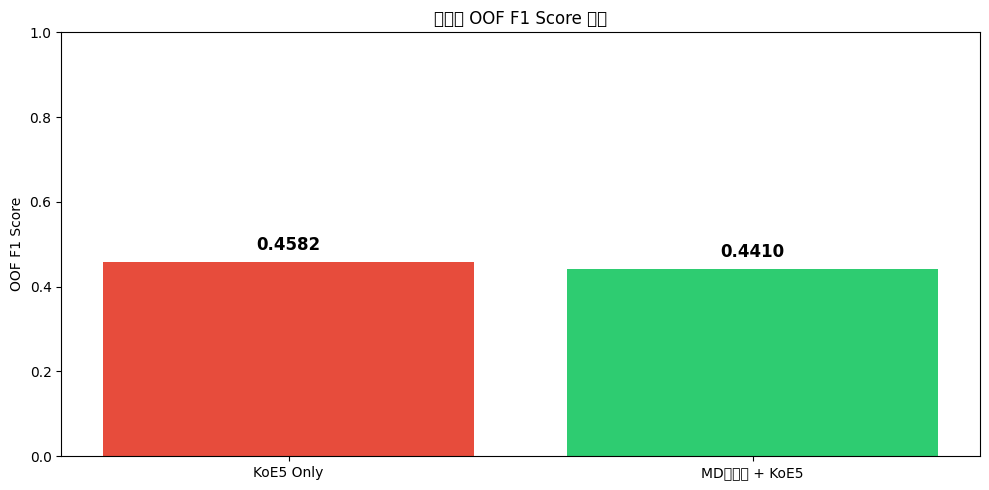


🎉 모든 실험 완료!


In [12]:
# ============================================================
# 📊 모델 비교 요약
# ============================================================

print("="*60)
print("📊 모델 비교 요약")
print("="*60)

# 변수 존재 여부 확인 및 기본값 설정
try:
    _oof_f1 = oof_f1
    _submission_path = submission_path
    _best_global_thr = best_global_thr
except NameError:
    _oof_f1 = 0.0
    _submission_path = "N/A (셀 3 실행 필요)"
    _best_global_thr = 0.5

try:
    _best_f1_emb = best_f1_emb
    _submission_path_emb = submission_path_emb
    _best_thr_emb = best_thr_emb
except NameError:
    _best_f1_emb = 0.0
    _submission_path_emb = "N/A (셀 5 실행 필요)"
    _best_thr_emb = 0.5

try:
    _best_f1_md = best_f1_md
    _submission_path_md = submission_path_md
    _best_thr_md = best_thr_md
except NameError:
    _best_f1_md = 0.0
    _submission_path_md = "N/A (셀 6 실행 필요)"
    _best_thr_md = 0.5

results = pd.DataFrame({
    '모델': ['기본 (정형+KoE5)', 'KoE5 Only', 'MD전처리 + KoE5'],
    'OOF F1': [_oof_f1, _best_f1_emb, _best_f1_md],
    'Best Threshold': [_best_global_thr, _best_thr_emb, _best_thr_md],
    '제출파일': [_submission_path, _submission_path_emb, _submission_path_md]
})

print("\n[OOF F1 Score 비교]")
print(results.to_string(index=False))

# 유효한 결과만 필터링
valid_results = results[results['OOF F1'] > 0]

if len(valid_results) > 0:
    # 최고 성능 모델 확인
    best_model_idx = valid_results['OOF F1'].idxmax()
    best_model = valid_results.loc[best_model_idx]

    print("\n" + "="*60)
    print("🏆 최고 성능 모델")
    print("="*60)
    print(f"모델: {best_model['모델']}")
    print(f"OOF F1 Score: {best_model['OOF F1']:.4f}")
    print(f"제출 파일: {best_model['제출파일']}")

    # 시각화
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    bars = ax.bar(valid_results['모델'], valid_results['OOF F1'], 
                  color=[colors[i] for i in valid_results.index])
    ax.set_ylabel('OOF F1 Score')
    ax.set_title('모델별 OOF F1 Score 비교')
    ax.set_ylim(0, 1)

    for bar, f1 in zip(bars, valid_results['OOF F1']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{f1:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ 아직 학습된 모델이 없습니다. 위 셀들을 먼저 실행해주세요.")

print("\n" + "="*60)
print("🎉 모든 실험 완료!")
print("="*60)